In [1]:
# This script is stolen heavily from Lambodhar Damodaran, with some bits from Anna Jaeger

In [2]:
import sys, subprocess, glob, os, shutil, re, importlib
from subprocess import call
import baltic as bt
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.lines as mlines
from matplotlib.font_manager import FontProperties
import matplotlib.colors as clr
import pandas as pd
import textwrap as textwrap
from textwrap import wrap
import numpy as np
from scipy.special import binom
from collections import defaultdict, Counter
from plotnine import *
from geopy.distance import geodesic
from geopy.distance import great_circle

In [2]:
# Function: To extract the lines with taxa information from the .trees file to add to .temp.tree
def get_taxa_lines(tree_path):    
    
    # write out a temp tree file
    temp_tree = tree_path.replace(".trees",".temp.tree")
    with open(temp_tree, "w") as outfile: 
        outfile.write("")

    lines_to_write = ""
    with open(tree_path) as infile:
        for line in infile: ## iterate through each line
            if 'state' not in line.lower(): #going to grab all the interesting stuff in the .trees file prior to the newick tree strings
                lines_to_write = lines_to_write + line

    return(lines_to_write)

In [14]:
# This dictionary allows me to maintain region-level discrete traits but have subtrees based on intros to North America

continent_dict = {"north-canada":"north-america",
                  "northeast-us":"north-america",
                  "northwest-us":"north-america",
                  "asia":"asia",
                  "east-canada":"north-america",
                  "europe":"europe",
                  "ancestor":"ancestor"
                 }

In [4]:
# Function: To extract subtrees
def retrieve_subtrees(tree, traitName, dictionary):
    
    # tree_strings = defaultdict(list)
    subtype_trees = defaultdict(list)
    region_transitions = Counter()
    continent_transitions = Counter()

    for i in tree.Objects:  # Iterate over branches
        k = i  # branch
        kp = i.parent  # branch's parent

        # Get current node's and its parent's trait states
        kloc = k.traits.get(traitName, 'ancestor')
        kploc = kp.traits.get(traitName, 'ancestor')
        kc = kloc  # Current branch trait value
        kpc = kploc  # Parent branch trait value

        # # Debug: print current and parent trait states
        # print(f"Node: {k} - Trait: {kc} | Parent: {kp} - Trait: {kpc}")
        # # Node: <baltic.baltic.node object at 0x110ae8850> - Trait: europe | Parent: <baltic.baltic.node object at 0x1326a9ad0> - Trait: ancestor

        # I only want to expand subtrees by introductions into North America
        kcont = dictionary[k.traits.get(traitName, 'ancestor')] # Current branch continent
        kpcont = dictionary[kp.traits.get(traitName, 'ancestor')] # Parent branch continent
        # print(f"Node: {k} - Trait: {kcont} | Parent: {kp} - Trait: {kpcont}")
        
        # Count transitions
        if kpc != kc:
            region_transitions[(kpc, kc)] += 1
            # print(f"Transition detected: {kpc} -> {kc}")

        if kpcont != kcont:
            continent_transitions[(kpcont, kcont)] += 1

        # If contienets do not match, extract subtree
        if kcont != kpcont:
            # traverse_condition = lambda w: w.traits.get(traitName, 'ancestor') == kc
            traverse_condition = lambda w: dictionary[w.traits.get(traitName, 'ancestor')] == kcont
            subtree = tree.subtree(k, traverse_condition=traverse_condition)
            
            if subtree:
                # print(f"Subtree extracted for transition: {kpc} -> {kc}")
                subtree.traverse_tree()  
                subtree.sortBranches()
                # tree_strings[kc].append(subtree.toString())
                subtype_trees[kcont].append((kpcont, subtree))
            else:
                print(f"Subtree extraction failed for {kpcont} -> {kcont}")

    # # Debug: Print final structures
    # print(f"Tree Strings: {dict(tree_strings)}")
    # print(f"Subtype Trees: {dict(subtype_trees)}")
    # print(f"Transitions: {dict(transitions)}")

    return subtype_trees, dict(region_transitions), dict(continent_transitions)

In [6]:
# Function: to count the number of transitions across the posterior
def count_transitions_distribution(tree_path, numtrees, burnin_percent, temp_tree):

    #count transitions in the posterior set of trees 
    # trees_per_file={}
    transitions_dict = {}
    treeCounter = 0
    burnin = int(numtrees * burnin_percent)

    # trees = bt.loadNexus(tree_path)
    with open(tree_path) as infile:
        for line in infile:

            # write an empty tree to read file; this will get filled in as a new nexus file for each tree in the posterior
            with open(temp_tree, "w") as outfile:
                outfile.write("")

            if 'tree STATE_' in line:
                treeCounter += 1
                if treeCounter > burnin:
                # if treeCounter < 5:
                    transitions_dict[f"tree{treeCounter}"] = {}
                    with open(temp_tree, "a") as outfile:
                        outfile.write(lines_to_write)
                        outfile.write(line)
                    tree = bt.loadNexus(temp_tree)

                    subtype_trees, region_transitions, continent_transitions = retrieve_subtrees(tree, "region", continent_dict)
                    # print(region_transitions)
                    # print(continent_transitions)
                    # transitions_dict[f"tree{treeCounter}"].update(region_transitions)
                    transitions_dict[f"tree{treeCounter}"].update(continent_transitions)

    return(transitions_dict)

In [7]:
# Tree path

# tree_path = "./BEAST/cont-phyl_dta/results/A6_concat_genome_DTA-contphyl_2025-12-28/A6_concat_genome_skyride_DTA-contphyl_2026-01-06_851combined_regionreplaced.trees"
# tree_path = "./SERAPHIM/A6_concat-genome_traits_2026-03-01_901combined_renamed.trees"
# tree_path = "./SERAPHIM/A6_concat-genome_traits_2026-03-10_901combined.trees"
tree_path = "./BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/A6_concat-gen_traits_2026-07-09_901combined.trees"

In [8]:
# Set the name of .temp.trees

temp_tree = tree_path.replace(".trees",".tempcomm.tree")

In [9]:
# Extract the taxa information from the .trees file to add to .temp.trees

lines_to_write = get_taxa_lines(tree_path)

In [10]:
transitions_across_posterior = count_transitions_distribution(tree_path, 901, 0.1, temp_tree)

KeyboardInterrupt: 

In [10]:
# print(transitions_across_posterior)

In [11]:
# Generate a dataframe and change the row names

df = pd.DataFrame(transitions_across_posterior).fillna(0).astype(int)
df.index = df.index.map(lambda x: f"{x[0]}_{x[1]}")

# regions_to_highlight = ["europe_east-canada", "east-canada_new-england", "east-canada_europe", "new-england_north-canada", "north-canada_pacific-northwest"]
# df_filtered = df[df.index.isin(regions_to_highlight)]
df_filtered = df[df.index != "ancestor_europe"]

In [12]:
print(len(df_filtered.columns))

811


In [13]:
# Melt this dataframe for plotting ease

df_long = (df_filtered.reset_index().rename(columns={'index': 'region_pair'}).melt(id_vars='region_pair',var_name='tree',value_name='count'))

In [17]:
# Change the names of region pairs for prettiness

df_long["region_pair_pretty"] = df_long["region_pair"].map({
    "europe_asia": "Europe - Asia",
    "europe_north-america": "Europe - North America",
    "north-america_asia": "North America - Asia",
    "north-america_europe": "North America - Europe",
})

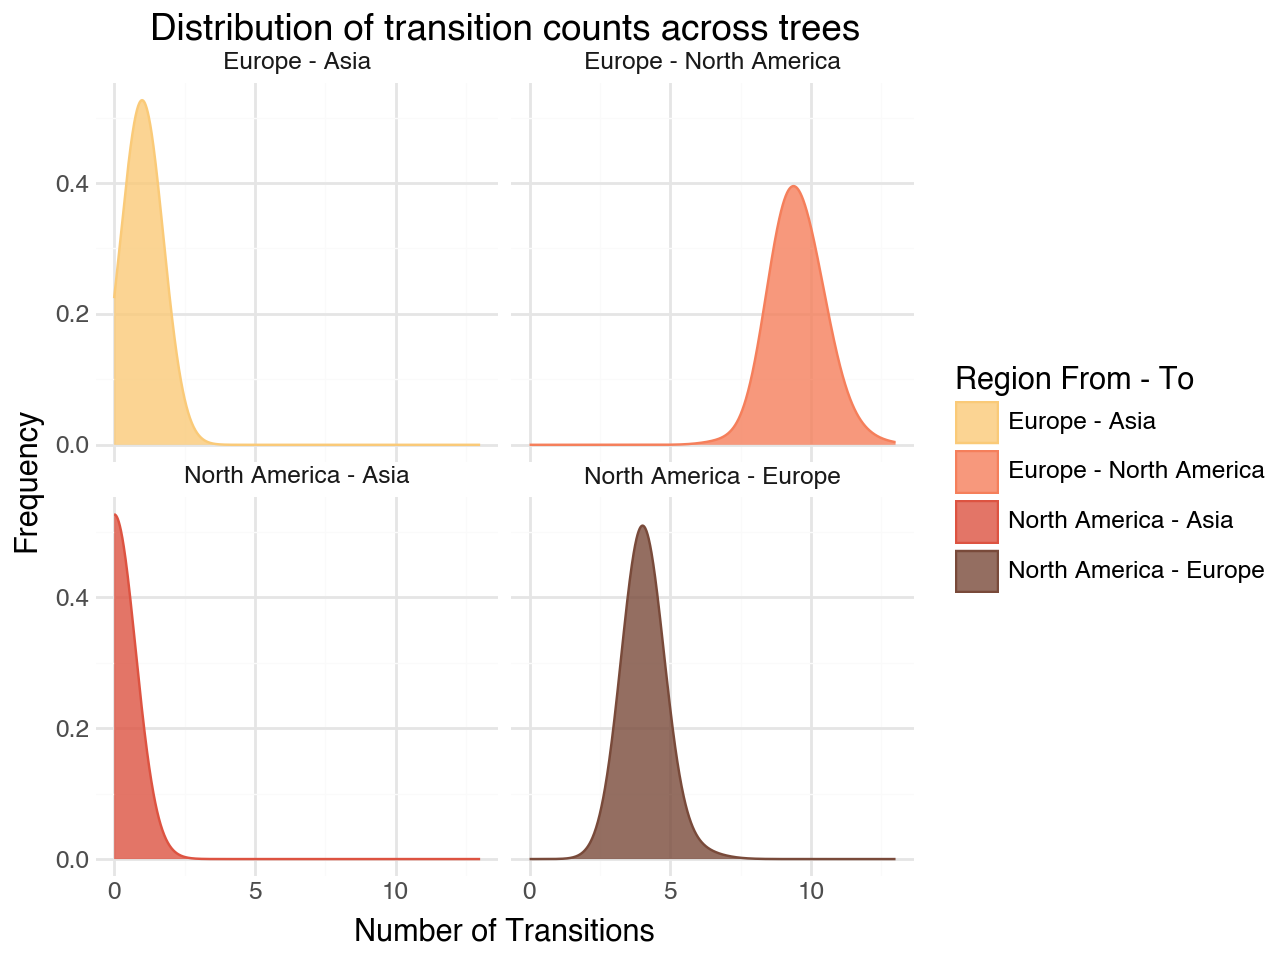

In [39]:
# Plot

colors = {"Europe - Asia":"#FACA78",
          "Europe - North America":"#F57F5B",
          "North America - Asia":"#DD5341",
          "North America - Europe":"#794A3A"}

transitions = (
    ggplot(df_long, aes(x='count', color = 'region_pair_pretty', fill='region_pair_pretty'))
    + geom_density(alpha=0.8, bw = 0.75) # default bandwidth (bw) looks to be about 0.15-0.2
    + facet_wrap("region_pair_pretty")
    + labs(title='Distribution of transition counts across trees',x='Number of Transitions',y='Frequency', color='Region From - To', fill='Region From - To')
    + scale_fill_manual(colors)
    + scale_color_manual(colors)
    + theme(figure_size = (15, 10))
    + theme_minimal()
)

transitions.show()

In [40]:
transitions.save("./SERAPHIM/output_plots/transitions_across_posterior.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/Users/claramal/miniconda3/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/output_plots/transitions_across_posterior.png


In [ ]:
# Plot the probability of hosts on each node of the MCC

In [4]:
# MCC = "./SERAPHIM/A6_concat-genome_traits_2026-03-01_MCC_renamed.tree"
# MCC = "./SERAPHIM/A6_concat-genome_traits_2026-03-10_MCC.tree"
# MCC = "./BEAST/cont-phyl_dta/results/2026-07-09_A6_concat_genome_traits/A6_concat-gen_traits_2026-07-09_MCC.tree"
MCC = "./BEAST/cont-phyl_dta/results/2026-08-04_A6_concat_genome_traits_TEST/A6_concat-gen_traits_2026-08-04_MCC.tree"

mcctree = bt.loadNexus(MCC, tip_regex='\|([0-9]{4}\-[0-9]{2}\-[0-9]{2})', absoluteTime=True, verbose=False)

In [5]:
mcctree.treeStats()


Tree height: 6.003206
Tree length: 113.765981
strictly bifurcating tree

Numbers of objects in tree: 723 (361 nodes and 362 leaves)



In [6]:
def node_host_prob(tree, MRSD):
    host_prob_dict = {}
    t = 1

    for k in tree.Objects:
        if k.is_leaf():
            pass
        elif k.traits == None:
            print("root")
        else:
            host = k.traits["host"]
            host_prob = k.traits["host.prob"]
            time = MRSD - k.traits["height"]

        host_prob_dict[t] = {"host": host, "prob": host_prob, "year": time}

        t += 1

    host_prob_df = pd.DataFrame(host_prob_dict).T

    host_prob_df['year'] = pd.to_numeric(host_prob_df['year'])
    host_prob_df['prob'] = pd.to_numeric(host_prob_df['prob'])

    print(len(host_prob_df.loc[host_prob_df["prob"] > 0.95]) / len(host_prob_df))

    return(host_prob_df)

In [7]:
# host_prob_df = node_host_prob(mcctree, 2025.8575342465754)
host_prob_df = node_host_prob(mcctree, 2026.0520547945205)

0.8616874135546335


In [8]:
host_prob_df['label'] = "86.17%"

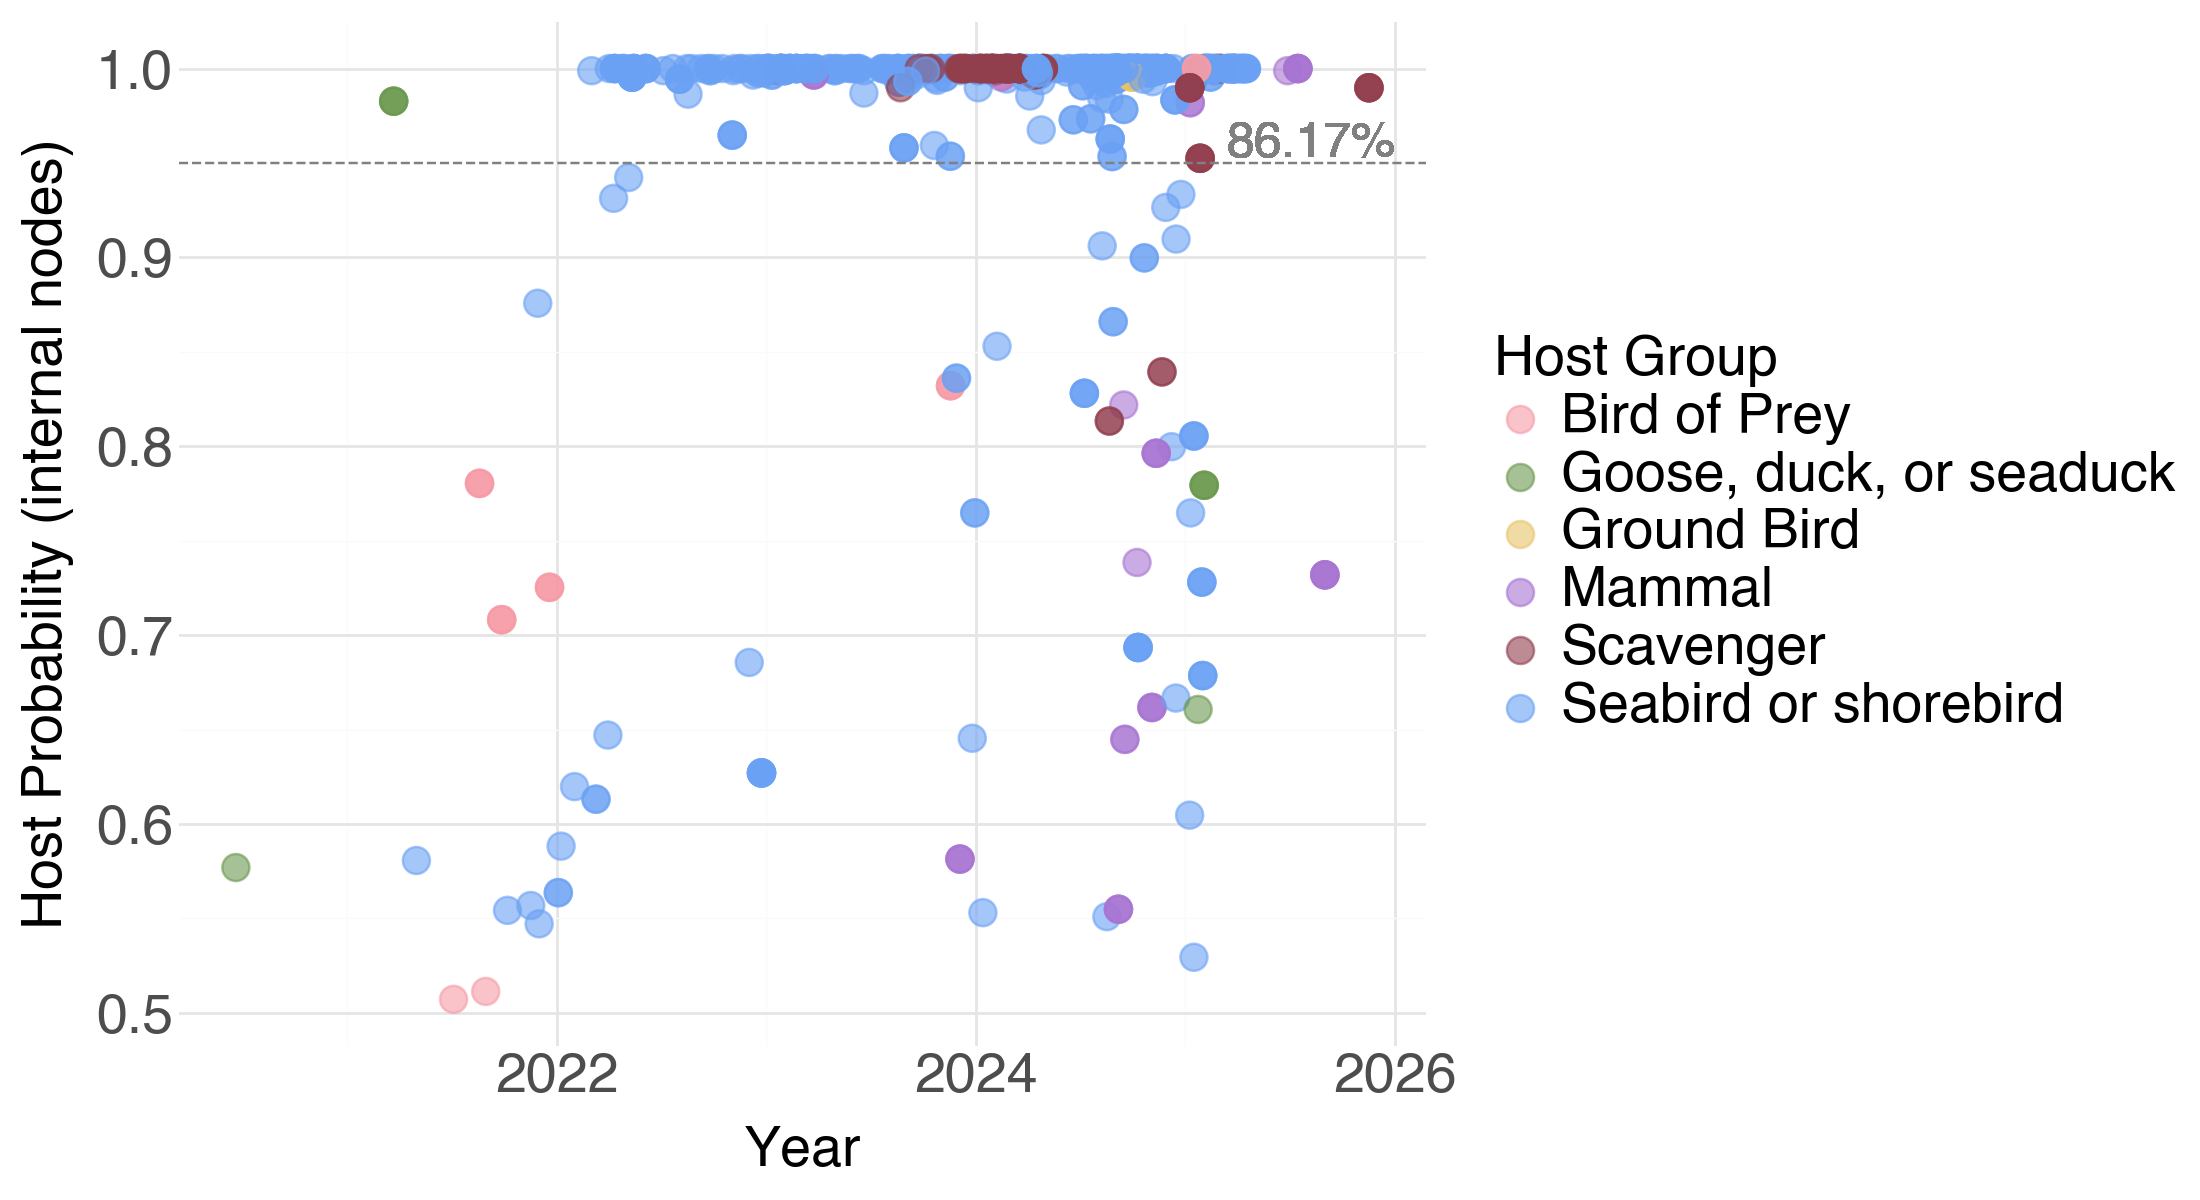

In [11]:
host_prob_plt = (
    ggplot(host_prob_df, aes(x = "year", y = "prob", color = "host"))
    + geom_point(size = 5, alpha = 0.6)
    + labs(x = "Year", y = "Host Probability (internal nodes)", color = "Host Group")
    + scale_color_manual(values = {"seab":"#6aa1f4", "bdpr": "#f69ba6", "gds": "#6a994e", "mammal": "#a874d2", "scav": "#923e4d", "grdbd": "#e9c46a"},
                        labels = {"bdpr":"Bird of Prey", "gds":"Goose, duck, or seaduck", "grdbd":"Ground Bird", "mammal":"Mammal", "scav":"Scavenger", "seab":"Seabird or shorebird"})
    + geom_hline(data = host_prob_df, linetype = "dashed", color = "grey", mapping = aes(yintercept = 0.95))
    + geom_text(data = host_prob_df, mapping=aes(x = 2025.6, y = 0.96, label = "label"), color = "grey", size = 18, ha = "center")
    + theme_minimal()
    + theme(figure_size = (11, 6), legend_text=element_text(size=20), legend_title = element_text(size = 20),
            axis_title_x = element_text(size = 20), axis_title_y = element_text(size = 20), text=element_text(size=20))
)

host_prob_plt.show()

In [12]:
# Print

host_prob_plt.save("./SERAPHIM/plots/host_probability_over_time.png", format = "png", dpi = 750)

/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 11 x 6 in image.
/Users/claramal/miniconda3/envs/analysis_env/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: ./SERAPHIM/plots/host_probability_over_time.png
